In [1]:
#Function 3

#You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.
#Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. 
#After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.Your goal is 
#to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output 
#(e.g. the negative of side effects)


In [4]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from scipy.interpolate import griddata

# Your 3D spatial coordinate data (10 positions)
inputs = np.load('/home/mcevoyj777/_CAPSTONE/FUNC3/initial_inputs.npy')

# Your ouput values
output = np.load('/home/mcevoyj777/_CAPSTONE/FUNC3/initial_outputs.npy')
print(output.max())
extra_inputs = [[0.426738, 0.378192, 0.522188],	[0.486387, 0.000001, 0.642801],
                [0.813402, 1.000000, 0.850601],[1.000000, 1.000000, 0.476485],
                [0.371791, 0.261877, 0.364875],[0.287828, 0.824693, 0.520877],
                [0.000000, 0.658499, 0.450000],[0.908225, 0.070294, 0.345820]]
extra_output = [-0.01887344507525891,-0.17955537260329268,-0.0742921891442901,
                -0.048658772455942204,-0.07871334921778922,-0.04888117186184354,
               -0.015571889914751325,-0.11154457534377356]

inputs = np.vstack([inputs, extra_inputs])
output = np.append(output, extra_output)

print(output.max())

print(inputs)
print(output)



# 2. Combine into a single Pandas DataFrame
df = pd.DataFrame(inputs, columns=['Input_X', 'Input_Y', 'Input_Z'])
df['Output_Target'] = output

# 3. Compute the correlation matrix
# Change method to 'spearman' if relationships are non-linear curves
corr_matrix = df.corr(method='pearson')

# 4. Isolate how each input correlates *only* with the target output
target_corr = corr_matrix['Output_Target'].drop('Output_Target')

print("Correlation with Output:")
print(target_corr)

# Calculate non-linear relationship dependency (higher score = stronger relationship)
mi_scores = mutual_info_regression(inputs, output)

for name, score in zip(['Input_X', 'Input_Y', 'Input_Z'], mi_scores):
    print(f"{name} Mutual Information Score: {score:.4f}")

# Fit a quick non-linear model that checks all 3 dimensions simultaneously
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(inputs, output)

# Extract total feature importances (including interactions)
importances = model.feature_importances_

for name, score in zip(['Input_X', 'Input_Y', 'Input_Z'], importances):
    print(f"{name} Total Importance (with interactions): {score:.4f}")

-0.034835313350078584
-0.015571889914751325
[[1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [9.65994849e-01 8.61119690e-01 5.66829131e-01]
 [4.26738000e-01 3.78192000e-01 5.22188000e-01]
 [4.86387000e-01 1.00000000e-06 6.42801000e-01]
 [8.13402000e-01 1.00000000e+00 8.50601000e-01]
 [1.00000000e+00 1.00000000e+00 4.76485000e-01]
 [3.71791000e-01 2.61877000e-01 3.64875000e-

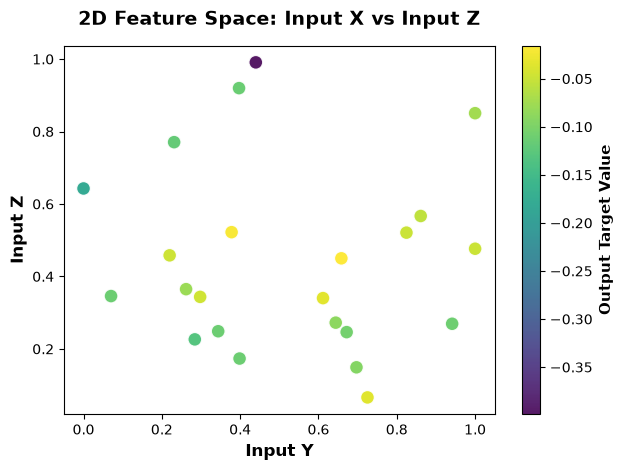

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Create scatter plot with a continuous color mapping (viridis)
scatter = plt.scatter(
    data=df, 
    x='Input_Y', 
    y='Input_Z', 
    c='Output_Target', 
    cmap='viridis', 
    s=100,            # Marker size
    edgecolor='w',    # White border around markers
    alpha=0.9
)

# Add elements
cbar = plt.colorbar(scatter)
cbar.set_label('Output Target Value', fontsize=11, fontweight='bold')
plt.xlabel('Input Y', fontsize=12, fontweight='bold')
plt.ylabel('Input Z', fontsize=12, fontweight='bold')
plt.title('2D Feature Space: Input X vs Input Z', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

In [17]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Train a predictive model on your 15 existing samples
predictor = RandomForestRegressor(n_estimators=100, random_state=42)
predictor.fit(inputs, output)

def objective_3d(X):
    """
    Surrogate function for 3D optimization.
    X: A 2D numpy array of shape (n_samples, 3) sent by the optimizer.
    """
    # Force input to be 2D array matrix for sklearn compatibility
    X = np.atleast_2d(X)
    
    # Predict the output value using the trained model
    predictions = predictor.predict(X)
    
    # Return as a flat 1D array as expected by your code (.ravel())
    return predictions.ravel()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

def upper_confidence_bound(mu, sigma, kappa=0.1):
    """
    Upper Confidence Bound (UCB) acquisition function.
    
    UCB = mean + kappa * std
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation
    kappa : exploration parameter (higher = more exploration)
    """
    return mu + kappa * sigma


def expected_improvement(mu, sigma, y_best, xi=0.1):
    """
    Expected Improvement (EI) acquisition function.
    
    EI = E[max(f(x) - f(x_best), 0)]
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation  
    y_best : best observed value so far
    xi : exploration parameter
    """
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

In [20]:
def bayesian_optimization_nd(objective_func, n_dims, n_iterations=1, 
                            n_initial=1, acquisition='ei'):
    """
    Bayesian Optimization for n-dimensional functions.
    Assumes bounds [0, 1] for all dimensions.
    """
    bounds = [(0, 1) for _ in range(n_dims)]
    
    # Initialize
    X_samples = inputs
    y_samples = output
    
    
    best_values = [y_samples.max()]
    
    print(f"Starting {n_dims}D optimization with {n_initial} initial samples...")
    print(f"Initial best: {y_samples.max():.4f}\n")

    
    # Initialize length scales: large for X and Y (ignores them), small/sensitive for Z
    # A large lengthscale tells the GP that moving along that axis changes nothing.
    init_length_scales = [0.5, 0.5, 0.5] 
        
    # Set bounds for the GP lengthscale optimizer
    # Crucial: Allow X and Y scales to grow massive, but let Z stay tight/sensitive
    length_scale_bounds = [
            (0.1, 100.0),   # Input_X bounds (ignore)
            (0.1, 100.0),   # Input_Y bounds (ignore)
            (0.01, 0.3)  # Input_Z bounds (forces focus here)
        ] 

    
    for iteration in range(n_iterations):
        # Fit GP
        kernel = ConstantKernel(1.0) * RBF(
            length_scale=init_length_scales, 
            length_scale_bounds=length_scale_bounds
        )
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,normalize_y=True,
                                     n_restarts_optimizer=15)
        gp.fit(X_samples, y_samples)

        # Optimize acquisition function
        def acq_objective(X):
            X = X.reshape(1, -1)
            mu, sigma = gp.predict(X, return_std=True)
            
            if acquisition == 'ei':
                acq_val = expected_improvement(mu, sigma, y_samples.max())
            else:
                acq_val = upper_confidence_bound(mu, sigma, kappa=1.0)
           
            return -acq_val
        
        # Multi-start optimization
        best_acq = np.inf
        X_next = None

        # Build dynamic, localized acquisition optimization bounds
        # X and Y remain free (0, 1). Z is focused tightly around the 0.52 peak zone.
        localized_bounds = [
            (0.0, 1.0),  # Input_X free global search
            (0.0, 1.0),  # Input_Y free global search
            (0.3, 0.6),  # Input_Z restricted hill-climbing window
        ]

        
        for _ in range(50):  # More starts for higher dimensions
            # Sample initial multi-start points respecting the localized constraints
            x0 = np.array(
                [
                    np.random.uniform(localized_bounds[0][0], bounds[0][1]),
                    np.random.uniform(localized_bounds[1][0], bounds[1][1]),
                    np.random.uniform(localized_bounds[2][0], bounds[2][1]),
                ]
            )
            result = minimize(acq_objective, x0, bounds=localized_bounds, method='L-BFGS-B',options={"ftol": 1e-9},)
            if result.fun < best_acq:
                best_acq = result.fun
                X_next = result.x
                print(f"Optimized Next Point Found! Predicted Acquisition Score: {-best_acq:.6f}")
                print(f"Coordinates to test next: {X_next}")

       
        # Evaluate
        y_next = objective_func(X_next.reshape(1, -1)).ravel()
        
        # Update
        X_samples = np.vstack([X_samples, X_next])
        y_samples = np.append(y_samples, y_next)
        best_values.append(y_samples.max())
        
        if (iteration + 1) % 10 == 0:
            print(f"Iteration {iteration + 1}: Best f(x)={y_samples.max():.4f}")
    
    return X_samples, y_samples, best_values



# Run 6D optimization
X_samples_3d, y_samples_3d, best_values_3d = bayesian_optimization_nd(
    objective_3d, 
    n_dims=3,
    n_iterations=5,
    acquisition=''
)

Starting 3D optimization with 1 initial samples...
Initial best: -0.0156

Optimized Next Point Found! Predicted Acquisition Score: 0.032057
Coordinates to test next: [0.         1.         0.40059818]
Optimized Next Point Found! Predicted Acquisition Score: 0.032057
Coordinates to test next: [0.         1.         0.40059832]
Optimized Next Point Found! Predicted Acquisition Score: -0.025553
Coordinates to test next: [0.  1.  0.6]
Optimized Next Point Found! Predicted Acquisition Score: -0.015761
Coordinates to test next: [0.         0.58058499 0.33960636]
Optimized Next Point Found! Predicted Acquisition Score: 0.004139
Coordinates to test next: [1.         0.47629211 0.48920028]
Optimized Next Point Found! Predicted Acquisition Score: 0.007141
Coordinates to test next: [0.         1.         0.45647379]
Optimized Next Point Found! Predicted Acquisition Score: 0.007141
Coordinates to test next: [0.         1.         0.45647383]
Optimized Next Point Found! Predicted Acquisition Score:

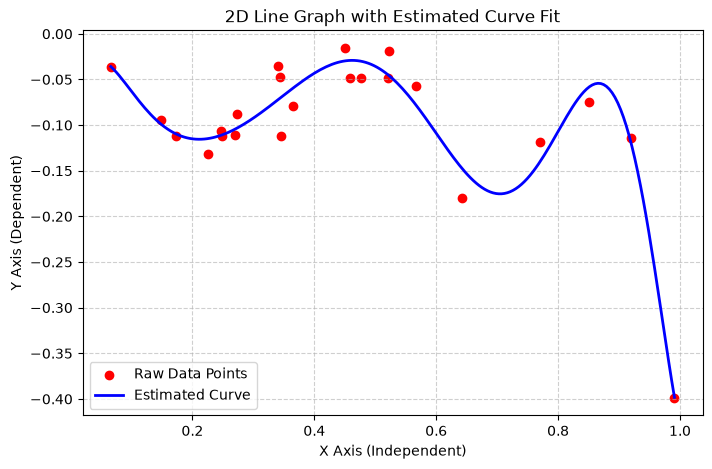

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create mock data (scattered data points)
x = df['Input_Z'].to_numpy() 
y = df['Output_Target'].to_numpy()  

# 2. Calculate the estimated curve line
# '2' means a degree-2 polynomial curve (quadratic: y = ax² + bx + c)
coefficients = np.polyfit(x, y, 9
                         )
polynomial = np.poly1d(coefficients)

# 3. Create a smooth line range for drawing the curve smoothly
x_smooth = np.linspace(x.min(), x.max(), 200)
y_estimated = polynomial(x_smooth)

# 4. Generate the 2D plot
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='red', label='Raw Data Points', zorder=1)
plt.plot(x_smooth, y_estimated, color='blue', label='Estimated Curve', linewidth=2)

# 5. Customise and display the graph
plt.title('2D Line Graph with Estimated Curve Fit')
plt.xlabel('X Axis (Independent)')
plt.ylabel('Y Axis (Dependent)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

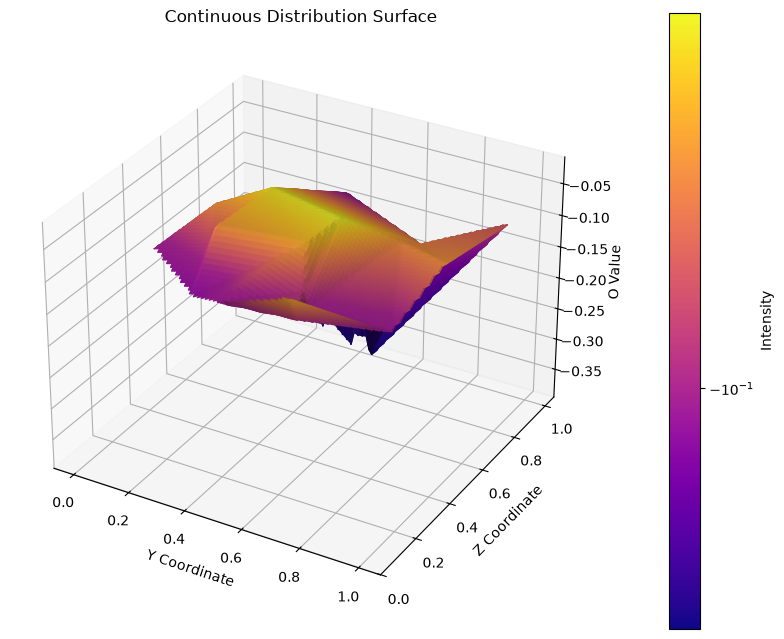

In [15]:

coords = (inputs[:,1],inputs[:,2])

# 1. Define a regular 2D grid based on your data boundaries
grid_x, grid_y = np.meshgrid(
    np.linspace(coords[0].min(), coords[0].max(), 100),
    np.linspace(coords[1].min(), coords[1].max(), 100)
)

# 2. Interpolate the scattered (x, y, z) data onto the uniform grid
# Options for method: 'linear', 'cubic', or 'nearest'
grid_z = griddata((coords[0], coords[1]), output, (grid_x, grid_y), method='linear')

# If your y_clean variable is different from values, interpolate it too for the colors
grid_color = griddata((coords[0], coords[1]), output, (grid_x, grid_y), method='linear')

# 3. Create the 3D surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
norm = colors.SymLogNorm(linthresh=0.1, vmin=output.min(), vmax=output.max())


# Plot the continuous surface
# facecolors overrides standard mapping to use your output
surf = ax.plot_surface(
    grid_x, grid_y, grid_z,
    facecolors=plt.cm.plasma(norm(grid_color)),
    rcount=100, ccount=100,  # Grid resolution
    antialiased=True,
    shade=True
)

# 4. Design elements
# Create a dummy scalar mappable object just to display the colorbar correctly
mappable = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
fig.colorbar(mappable, ax=ax, label="Intensity", pad=0.1)

ax.set_xlabel("Y Coordinate")
ax.set_ylabel("Z Coordinate")
ax.set_zlabel("O Value")
ax.set_title("Continuous Distribution Surface")

plt.show()